In [1]:
import pandas as pd

In [2]:
%run "Main_Preprocessing_2.py"

C:\Users\shibu\OneDrive\Desktop\ALLAN\Projects in Data Science\GDSC\TRIAL for me\Main_Preprocessing_2.py:10: DtypeWarning: Columns (0: Recurrent Gain Loss, 1: Genes in Segment) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("genomic_features.csv")


Data loaded:
  df shape : (242035, 19)
  df2 shape: (698000, 9)
  df3 shape: (2266, 96)
  df4 shape: (2132, 49)

After MSI and Growth fill:
  MSI missing         : 630
  Growth Prop missing : 0

After tissue descriptor fills:
  GDSC Tissue descriptor 1 missing: 0
  GDSC Tissue descriptor 2 missing: 0

After feature column cleaning — missing counts:
TARGET                                     27872
DRUG_NAME                                      0
TCGA_DESC                                   1067
Microsatellite instability Status (MSI)      630
Growth Properties                              0
GDSC Tissue descriptor 1                       0
GDSC Tissue descriptor 2                       0

TCGA Stage 1 fill results:
  Missing before                             : 1067
  Filled from cancer-type column             : 360
  Filled manually                            : 707
  Filled from Tissue descriptor 2 (unique)  : 0
  Missing after                              : 0

TCGA Stage 2 (OTHER -> PRA

In [3]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)

(193628, 146)
(48407, 146)
(193628,)
(48407,)


In [5]:
needed = ["X_train_scaled", "X_test_scaled", "y_train", "y_test"]
for name in needed:
    print(name, "->", name in globals())

X_train_scaled -> True
X_test_scaled -> True
y_train -> True
y_test -> True


In [7]:
%run -i "Main_modeling_2.py"

Modeling data used:
  X_train rows: 193628
  X_test rows : 48407
  Features    : 146

CatBoost tuned
Hyperparameters:
  iterations: 1500
  learning_rate: 0.13558330321686268
  depth: 10
  l2_leaf_reg: 0.01578981814610257
  subsample: 0.7502720766157313
  random_strength: 0.0035710492569881653
  bagging_temperature: 2.863575984094419
  min_data_in_leaf: 12
  loss_function: RMSE
  eval_metric: R2
  verbose: 0
  random_state: 42
Metrics:
  RMSE: 1.041411
  MAE : 0.777037
  R2  : 0.857843

XGBoost tuned
Hyperparameters:
  n_estimators: 1600
  learning_rate: 0.0606212053346252
  max_depth: 10
  min_child_weight: 3
  subsample: 0.8664841675523584
  colsample_bytree: 0.663669197027016
  gamma: 0.41282236439827835
  reg_alpha: 0.001139884908293192
  reg_lambda: 5.4367797220761656
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1
  tree_method: hist
Metrics:
  RMSE: 1.041933
  MAE : 0.777403
  R2  : 0.857700

LightGBM tuned
Hyperparameters:
  max_depth: 13
  n_estimators: 1750
  lea

In [8]:
# Clean tuned results table
results_display = results_df.copy()
results_display["RMSE"] = results_display["RMSE"].round(6)
results_display["MAE"] = results_display["MAE"].round(6)
results_display["R2"] = results_display["R2"].round(6)

display(results_display)

,Model,RMSE,MAE,R2
0,CatBoost tuned,1.041411,0.777037,0.857843
1,XGBoost tuned,1.041933,0.777403,0.857700
2,LightGBM tuned,1.047572,0.781412,0.856156


In [9]:
# Add rank and identify best model
results_ranked = results_display.copy()
results_ranked["Rank"] = range(1, len(results_ranked) + 1)

best_model_name = results_ranked.iloc[0]["Model"]
best_model_r2 = results_ranked.iloc[0]["R2"]
best_model_rmse = results_ranked.iloc[0]["RMSE"]
best_model_mae = results_ranked.iloc[0]["MAE"]

display(results_ranked)

print("Best tuned model:")
print(f"Model: {best_model_name}")
print(f"R2   : {best_model_r2:.6f}")
print(f"RMSE : {best_model_rmse:.6f}")
print(f"MAE  : {best_model_mae:.6f}")

,Model,RMSE,MAE,R2,Rank
0,CatBoost tuned,1.041411,0.777037,0.857843,1
1,XGBoost tuned,1.041933,0.777403,0.857700,2
2,LightGBM tuned,1.047572,0.781412,0.856156,3


Best tuned model:
Model: CatBoost tuned
R2   : 0.857843
RMSE : 1.041411
MAE  : 0.777037


In [10]:
# Compare each tuned model against the best model
best_row = results_ranked.iloc[0]

comparison_to_best = results_ranked.copy()
comparison_to_best["Delta_RMSE_vs_Best"] = comparison_to_best["RMSE"] - best_row["RMSE"]
comparison_to_best["Delta_MAE_vs_Best"] = comparison_to_best["MAE"] - best_row["MAE"]
comparison_to_best["Delta_R2_vs_Best"] = comparison_to_best["R2"] - best_row["R2"]

display(comparison_to_best.round(6))

,Model,RMSE,MAE,R2,Rank,Delta_RMSE_vs_Best,Delta_MAE_vs_Best,Delta_R2_vs_Best
0,CatBoost tuned,1.041411,0.777037,0.857843,1,0.000000,0.000000,0.000000
1,XGBoost tuned,1.041933,0.777403,0.857700,2,0.000522,0.000366,-0.000143
2,LightGBM tuned,1.047572,0.781412,0.856156,3,0.006161,0.004375,-0.001687


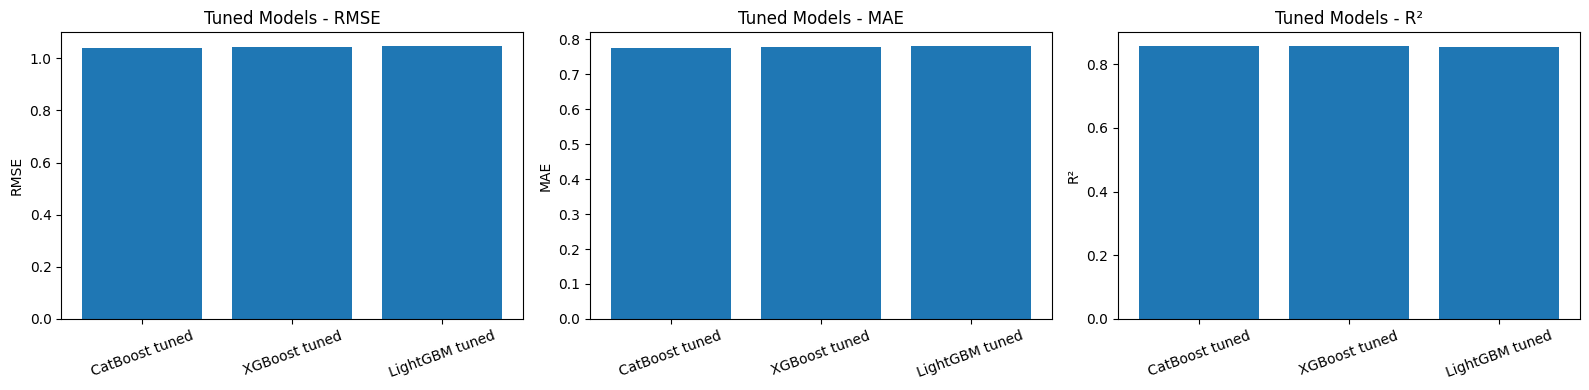

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = results_ranked.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# RMSE
axes[0].bar(plot_df["Model"], plot_df["RMSE"])
axes[0].set_title("Tuned Models - RMSE")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

# MAE
axes[1].bar(plot_df["Model"], plot_df["MAE"])
axes[1].set_title("Tuned Models - MAE")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)

# R2
axes[2].bar(plot_df["Model"], plot_df["R2"])
axes[2].set_title("Tuned Models - R²")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("tuned_model_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

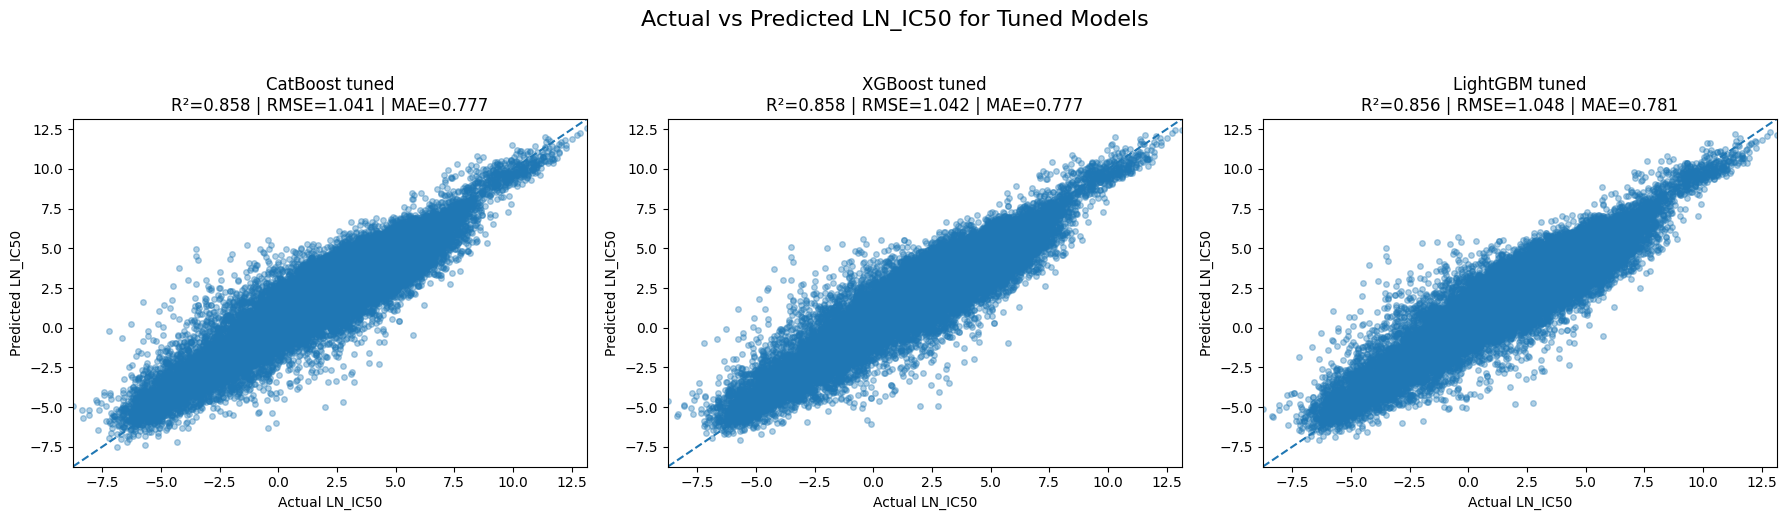

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

predictions_tuned = {
    "CatBoost tuned": y_pred_cat,
    "XGBoost tuned": y_pred_xgb,
    "LightGBM tuned": y_pred_lgbm,
}

y_true = np.array(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = np.array(axes).reshape(-1)

for ax, (model_name, y_pred) in zip(axes, predictions_tuned.items()):
    y_pred = np.array(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    xy_min = min(y_true.min(), y_pred.min())
    xy_max = max(y_true.max(), y_pred.max())

    ax.scatter(y_true, y_pred, alpha=0.35, s=16)
    ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=1.5)

    ax.set_title(f"{model_name}\nR²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
    ax.set_xlabel("Actual LN_IC50")
    ax.set_ylabel("Predicted LN_IC50")
    ax.set_xlim(xy_min, xy_max)
    ax.set_ylim(xy_min, xy_max)

plt.suptitle("Actual vs Predicted LN_IC50 for Tuned Models", fontsize=16, y=1.03)
plt.tight_layout()
plt.savefig("tuned_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

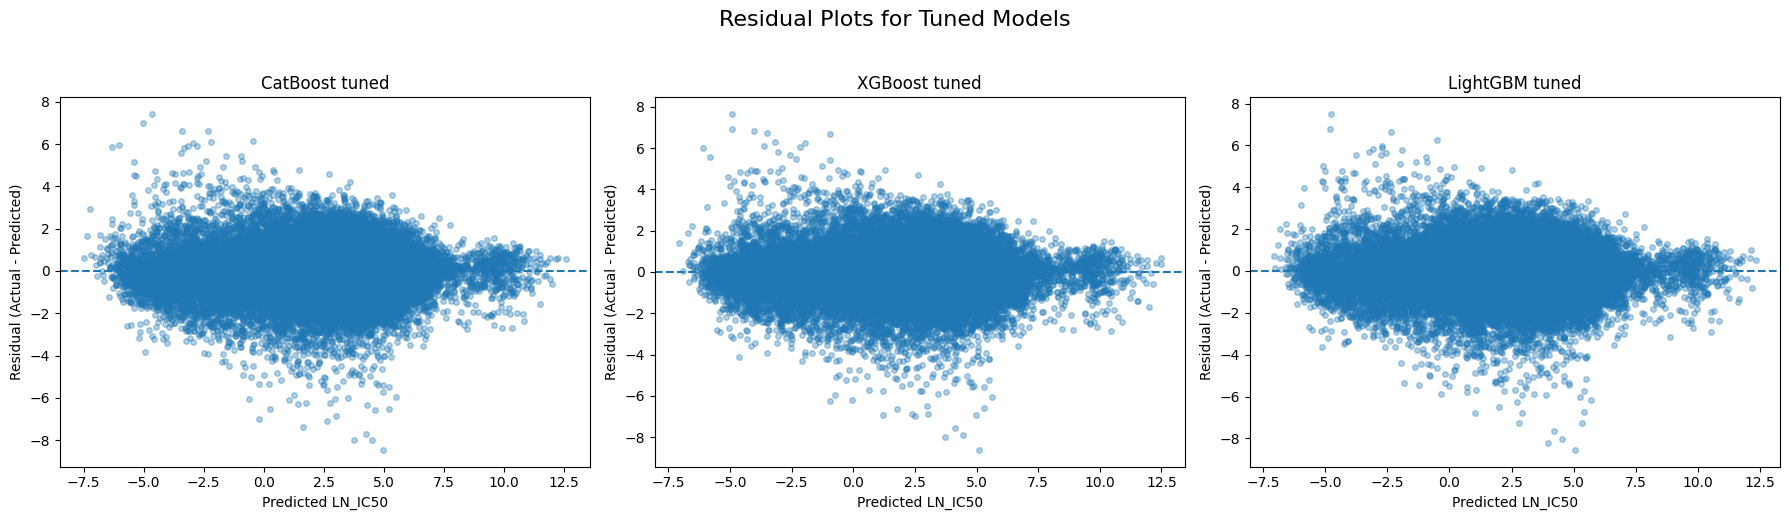

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = np.array(axes).reshape(-1)

for ax, (model_name, y_pred) in zip(axes, predictions_tuned.items()):
    y_pred = np.array(y_pred)
    residuals = y_true - y_pred

    ax.scatter(y_pred, residuals, alpha=0.35, s=16)
    ax.axhline(0, linestyle="--", linewidth=1.5)

    ax.set_title(model_name)
    ax.set_xlabel("Predicted LN_IC50")
    ax.set_ylabel("Residual (Actual - Predicted)")

plt.suptitle("Residual Plots for Tuned Models", fontsize=16, y=1.03)
plt.tight_layout()
plt.savefig("tuned_residual_plots.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
import pandas as pd

safe_to_original = dict(zip(feature_map["safe_name"], feature_map["original_name"]))

# CatBoost importance
cat_imp = pd.DataFrame({
    "Feature": X_train_model.columns,
    "Importance": cat_model.get_feature_importance()
})
cat_imp["Feature"] = cat_imp["Feature"].map(lambda x: safe_to_original.get(x, x))
cat_imp = cat_imp.sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 CatBoost tuned features")
display(cat_imp.head(15))

# XGBoost importance
xgb_imp = pd.DataFrame({
    "Feature": X_train_safe.columns,
    "Importance": xgb_model.feature_importances_
})
xgb_imp["Feature"] = xgb_imp["Feature"].map(lambda x: safe_to_original.get(x, x))
xgb_imp = xgb_imp.sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 XGBoost tuned features")
display(xgb_imp.head(15))

# LightGBM importance
lgb_imp = pd.DataFrame({
    "Feature": X_train_safe.columns,
    "Importance": lgbm_model.feature_importances_
})
lgb_imp["Feature"] = lgb_imp["Feature"].map(lambda x: safe_to_original.get(x, x))
lgb_imp = lgb_imp.sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 LightGBM tuned features")
display(lgb_imp.head(15))

Top 15 CatBoost tuned features


,Feature,Importance
0,DRUG_NAME_target_enc,31.630180
1,mutational_burden,10.468298
2,ploidy_wes,10.291938
3,ploidy_snp6,8.620349
4,Growth Properties_Suspension,6.862064
5,TARGET_PATHWAY_ERK MAPK signaling,2.362935
6,TARGET_PATHWAY_DNA replication,1.287688
7,TARGET_PATHWAY_Apoptosis regulation,1.079955
8,TCGA_DESC_SCLC,1.076396
9,TARGET_PATHWAY_PI3K/MTOR signaling,0.981120


Top 15 XGBoost tuned features


,Feature,Importance
0,TARGET_PATHWAY_Mitosis,0.085053
1,Growth Properties_Suspension,0.066671
2,DRUG_NAME_target_enc,0.045802
3,TARGET_PATHWAY_Protein stability and degradation,0.029176
4,GDSC Tissue descriptor 1_leukemia,0.021940
5,TARGET_PATHWAY_Cell cycle,0.018323
6,GDSC Tissue descriptor 2_digestive_system_other,0.012969
7,TARGET_PATHWAY_JNK and p38 signaling,0.011518
8,TARGET_PATHWAY_Metabolism,0.011395
9,GDSC Tissue descriptor 2_melanoma,0.011258


Top 15 LightGBM tuned features


,Feature,Importance
0,DRUG_NAME_target_enc,71568
1,mutational_burden,50584
2,ploidy_snp6,47880
3,ploidy_wes,44492
4,TARGET_PATHWAY_DNA replication,4428
5,TARGET_PATHWAY_PI3K/MTOR signaling,4253
6,TARGET_PATHWAY_ERK MAPK signaling,3831
7,TARGET_PATHWAY_Unclassified,3402
8,"TARGET_PATHWAY_Other, kinases",2588
9,TARGET_PATHWAY_Apoptosis regulation,2567


In [15]:
top_n = 15

cat_top = set(cat_imp.head(top_n)["Feature"])
xgb_top = set(xgb_imp.head(top_n)["Feature"])
lgb_top = set(lgb_imp.head(top_n)["Feature"])

print("Shared across all 3 tuned models:")
print(sorted(cat_top & xgb_top & lgb_top))

print("\nShared across at least 2 tuned models:")
print(sorted((cat_top & xgb_top) | (cat_top & lgb_top) | (xgb_top & lgb_top)))

Shared across all 3 tuned models:
['DRUG_NAME_target_enc']

Shared across at least 2 tuned models:
['DRUG_NAME_target_enc', 'GDSC Tissue descriptor 1_leukemia', 'GDSC Tissue descriptor 2_melanoma', 'Growth Properties_Adherent', 'Growth Properties_Suspension', 'TARGET_PATHWAY_Apoptosis regulation', 'TARGET_PATHWAY_DNA replication', 'TARGET_PATHWAY_EGFR signaling', 'TARGET_PATHWAY_ERK MAPK signaling', 'TARGET_PATHWAY_Mitosis', 'TARGET_PATHWAY_PI3K/MTOR signaling', 'TCGA_DESC_SCLC', 'mutational_burden', 'ploidy_snp6', 'ploidy_wes']


# baseline

In [3]:
# Cell 1: imports
import warnings
warnings.filterwarnings("ignore")

import runpy
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [4]:
# Cell 2: run the preprocessing script and collect outputs
# Change the file name below only if your notebook uses a different preprocessing file name.
prep = runpy.run_path("Main_Preprocessing_2.py")

X_train_scaled = prep["X_train_scaled"].copy()
X_test_scaled  = prep["X_test_scaled"].copy()
y_train = prep["y_train"].copy()
y_test  = prep["y_test"].copy()

print("Loaded preprocessing outputs:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

Data loaded:
  df shape : (242035, 19)
  df2 shape: (698000, 9)
  df3 shape: (2266, 96)
  df4 shape: (2132, 49)

After MSI and Growth fill:
  MSI missing         : 630
  Growth Prop missing : 0

After tissue descriptor fills:
  GDSC Tissue descriptor 1 missing: 0
  GDSC Tissue descriptor 2 missing: 0

After feature column cleaning — missing counts:
TARGET                                     27872
DRUG_NAME                                      0
TCGA_DESC                                   1067
Microsatellite instability Status (MSI)      630
Growth Properties                              0
GDSC Tissue descriptor 1                       0
GDSC Tissue descriptor 2                       0

TCGA Stage 1 fill results:
  Missing before                             : 1067
  Filled from cancer-type column             : 360
  Filled manually                            : 707
  Filled from Tissue descriptor 2 (unique)  : 0
  Missing after                              : 0

TCGA Stage 2 (OTHER -> PRA

In [10]:
# Cell: make all feature names LightGBM-safe and guaranteed unique

import re
import pandas as pd

def make_unique_feature_names(columns):
    seen = {}
    new_cols = []

    for col in columns:
        col = str(col).strip()

        # Make names LightGBM-safe and consistent
        safe = re.sub(r"[^0-9a-zA-Z_]+", "_", col)   # replace spaces/punctuation with _
        safe = re.sub(r"_+", "_", safe)              # collapse repeated underscores
        safe = safe.strip("_")

        if safe == "":
            safe = "feature"

        # Ensure uniqueness after cleaning
        if safe in seen:
            seen[safe] += 1
            safe = f"{safe}__dup{seen[safe]}"
        else:
            seen[safe] = 0

        new_cols.append(safe)

    return new_cols

print("Before renaming:")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

new_train_cols = make_unique_feature_names(X_train_scaled.columns)
new_test_cols = make_unique_feature_names(X_test_scaled.columns)

# Use train column names for both so they stay aligned
X_train_scaled = X_train_scaled.copy()
X_test_scaled = X_test_scaled.copy()

X_train_scaled.columns = new_train_cols
X_test_scaled.columns = new_train_cols

print("\nAfter renaming:")
print("Unique train columns:", X_train_scaled.columns.nunique())
print("Total train columns :", len(X_train_scaled.columns))

dup_cols_after = X_train_scaled.columns[X_train_scaled.columns.duplicated()].tolist()
print("Duplicates remaining:", len(dup_cols_after))

print("\nSample columns:")
print(X_train_scaled.columns[:20].tolist())

Before renaming:
X_train_scaled shape: (193628, 146)
X_test_scaled shape : (48407, 146)

After renaming:
Unique train columns: 146
Total train columns : 146
Duplicates remaining: 0

Sample columns:
['TCGA_DESC_ACC', 'TCGA_DESC_ALL', 'TCGA_DESC_BLCA', 'TCGA_DESC_BRCA', 'TCGA_DESC_CESC', 'TCGA_DESC_CLL', 'TCGA_DESC_COREAD', 'TCGA_DESC_DLBC', 'TCGA_DESC_ESCA', 'TCGA_DESC_GBM', 'TCGA_DESC_HNSC', 'TCGA_DESC_KIRC', 'TCGA_DESC_LAML', 'TCGA_DESC_LCML', 'TCGA_DESC_LGG', 'TCGA_DESC_LIHC', 'TCGA_DESC_LUAD', 'TCGA_DESC_LUSC', 'TCGA_DESC_MB', 'TCGA_DESC_MESO']


In [11]:
# Cell 3: define baseline models
# These are kept close to default/minimal settings so they behave like baseline models.

models = {
    "CatBoost": CatBoostRegressor(
        random_seed=42,
        verbose=0
    ),
    
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    
    "MLPRegressor": MLPRegressor(
        random_state=42,
        max_iter=300
    ),
    
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    ),
    
    "LightGBM": LGBMRegressor(
        random_state=42,
        verbose=-1
    ),
    
    "ExtraTrees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),
    
    "Ridge": Ridge()
}

In [12]:
results = []
predictions = {}
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    try:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

        predictions[model_name] = y_pred
        trained_models[model_name] = model

    except Exception as e:
        print(f"{model_name} failed: {e}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df)

Training CatBoost...
Training XGBoost...
Training MLPRegressor...
Training HistGradientBoosting...
Training LightGBM...
Training ExtraTrees...
Training Ridge...


,Model,RMSE,MAE,R2
0,CatBoost,1.132169,0.843563,0.831986
1,XGBoost,1.140523,0.851656,0.829497
2,MLPRegressor,1.182636,0.888743,0.816673
3,LightGBM,1.229644,0.916978,0.801810
4,HistGradientBoosting,1.230592,0.916503,0.801504
5,ExtraTrees,1.232253,0.911635,0.800968
6,Ridge,1.344522,1.007612,0.763048


In [13]:
# Cell: feature importance from CatBoost and XGBoost

import pandas as pd

feature_names = X_train_scaled.columns.tolist()

importance_tables = {}

for model_name in ["CatBoost", "XGBoost"]:
    model = trained_models[model_name]
    
    if model_name == "CatBoost":
        importances = model.get_feature_importance()
    else:
        importances = model.feature_importances_
    
    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    
    importance_tables[model_name] = imp_df
    
    print(f"\nTop 15 features for {model_name}")
    display(imp_df.head(15))


Top 15 features for CatBoost


,Feature,Importance
0,DRUG_NAME_target_enc,52.233626
1,ploidy_wes,7.435730
2,mutational_burden,6.868373
3,Growth_Properties_Suspension,6.782117
4,ploidy_snp6,6.470171
5,TARGET_PATHWAY_ERK_MAPK_signaling,1.713995
6,GDSC_Tissue_descriptor_1_leukemia,1.342382
7,GDSC_Tissue_descriptor_1_lymphoma,0.816106
8,Growth_Properties_Adherent,0.618551
9,TCGA_DESC_NB,0.613951



Top 15 features for XGBoost


,Feature,Importance
0,Growth_Properties_Suspension,0.135220
1,DRUG_NAME_target_enc,0.126386
2,GDSC_Tissue_descriptor_1_leukemia,0.022176
3,TCGA_DESC_SCLC,0.021394
4,GDSC_Tissue_descriptor_2_melanoma,0.021156
5,TCGA_DESC_PAAD,0.018818
6,GDSC_Tissue_descriptor_1_blood,0.017471
7,GDSC_Tissue_descriptor_2_lymphoid_neoplasm_other,0.017121
8,GDSC_Tissue_descriptor_1_lymphoma,0.016868
9,GDSC_Tissue_descriptor_2_rhabdomyosarcoma,0.016307


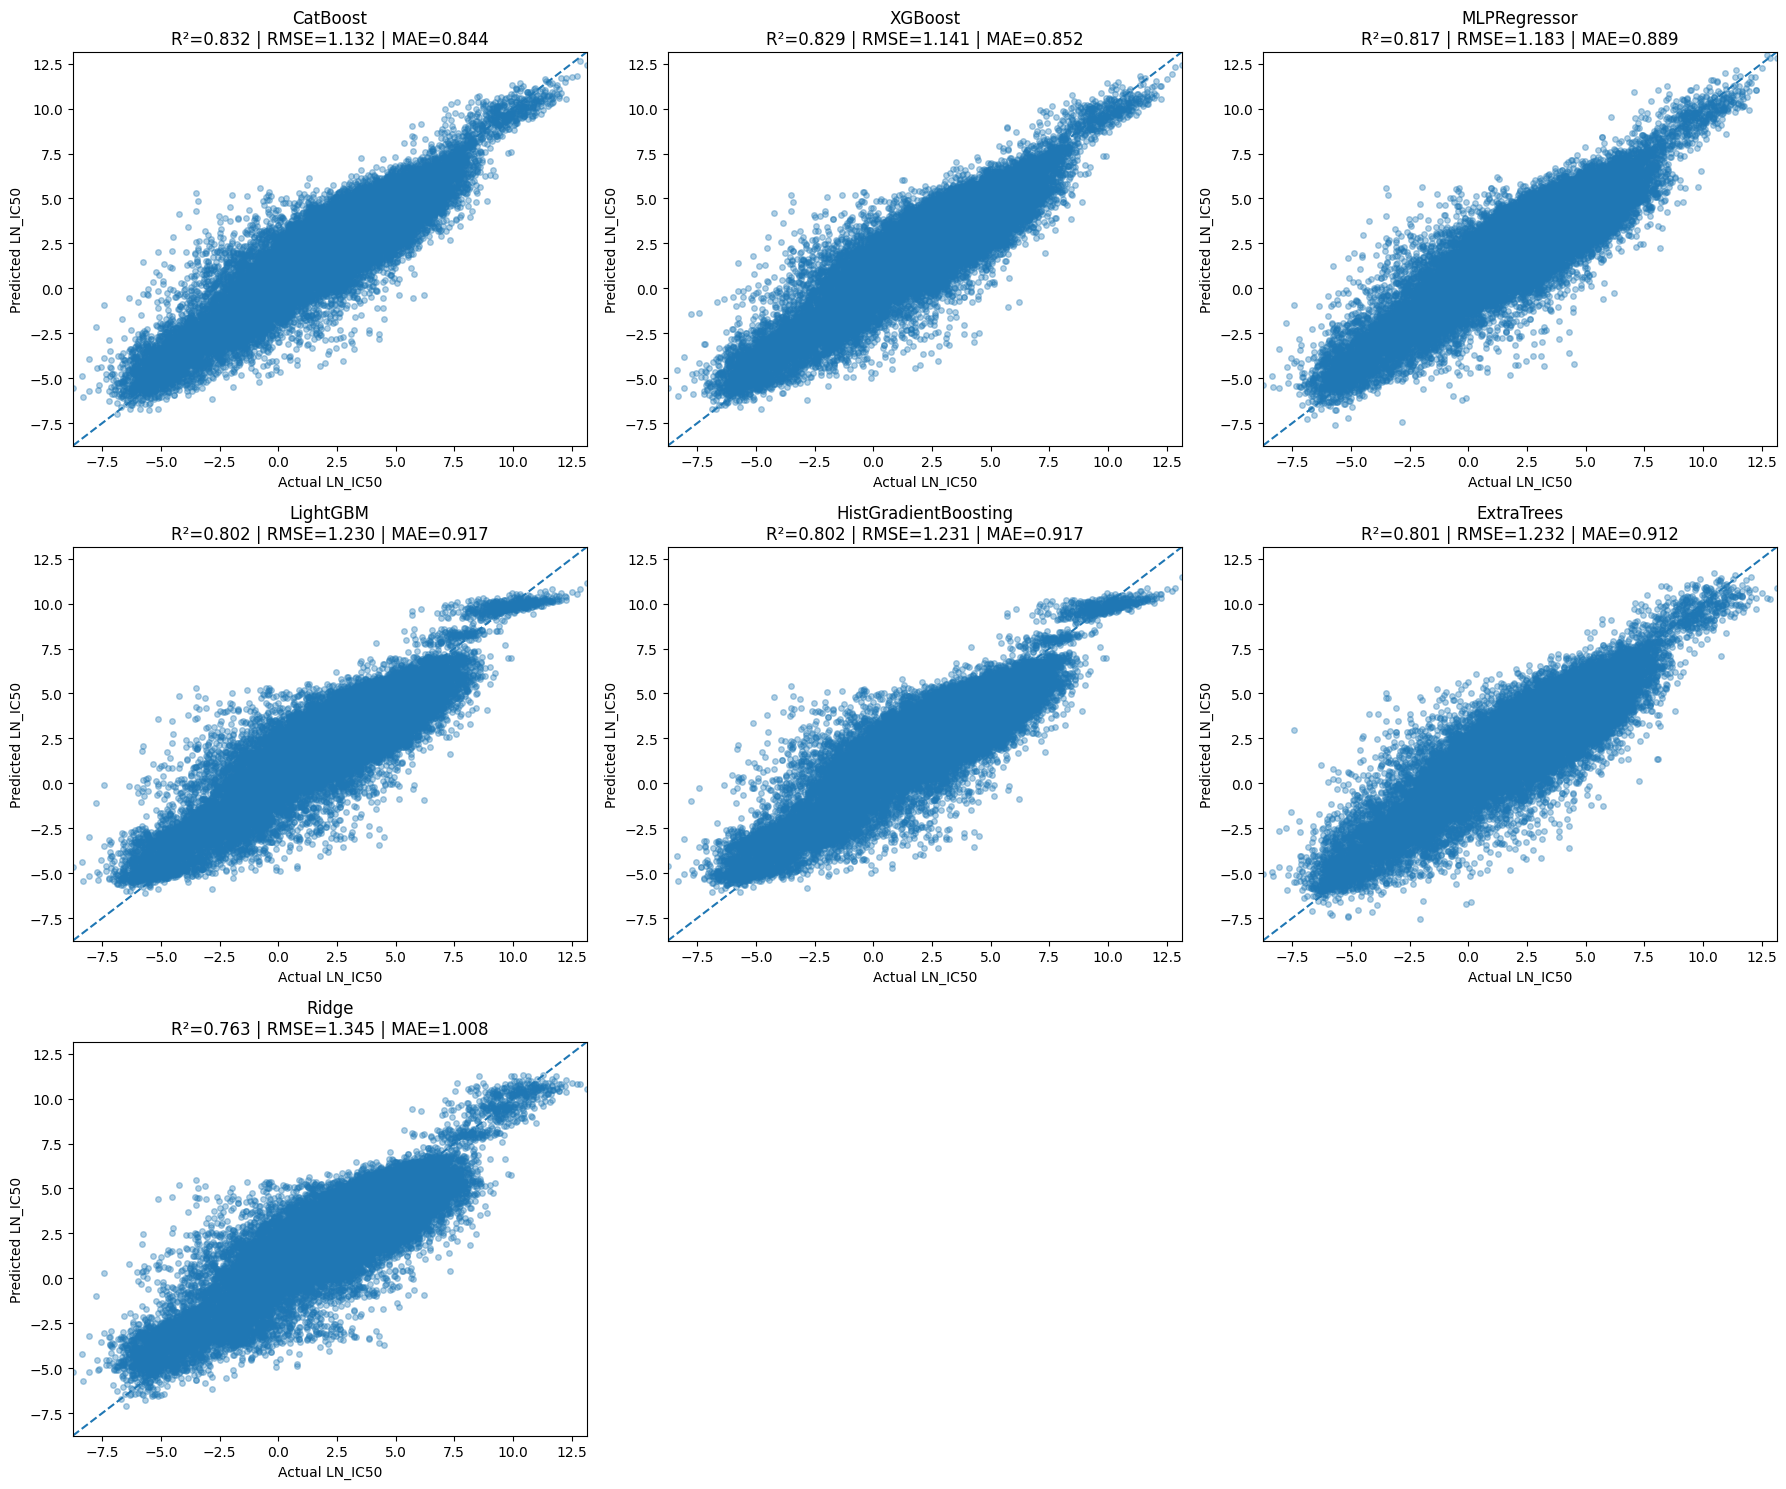

<Figure size 640x480 with 0 Axes>

In [17]:
# Actual vs Predicted scatter plots for all trained baseline models

import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Make sure y_test is a 1D numpy array
y_true = np.array(y_test)

# Use model order from results table if available; otherwise use predictions dict order
if "results_df" in globals() and not results_df.empty:
    model_order = results_df["Model"].tolist()
else:
    model_order = list(predictions.keys())

n_models = len(model_order)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, model_name in enumerate(model_order):
    ax = axes[i]
    y_pred = np.array(predictions[model_name])

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # shared min/max for diagonal line
    xy_min = min(y_true.min(), y_pred.min())
    xy_max = max(y_true.max(), y_pred.max())

    ax.scatter(y_true, y_pred, alpha=0.35, s=16)
    ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=1.5)

    ax.set_title(f"{model_name}\nR²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
    ax.set_xlabel("Actual LN_IC50")
    ax.set_ylabel("Predicted LN_IC50")
    ax.set_xlim(xy_min, xy_max)
    ax.set_ylim(xy_min, xy_max)

# Remove unused axes if fewer than grid size
for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("actual_vs_predicted_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

plt.suptitle("Actual vs Predicted LN_IC50 for Baseline Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()